# Interactive one-shot G0W0 for graphene

In this notebook, we assemble a one-shot $G_0W_0$ calculation for graphene from QAssemble's public Python objects, without going through the CLI. We verify the chemical potential and particle number, then compare the tight-binding and quasiparticle bands.

Run this from an environment where QAssemble is installed, or set `PYTHONPATH=src` from the repository root. Real-frequency spectral functions are out of scope: they require analytic continuation, which QAssemble does not yet expose as a stable API.

In [1]:
from contextlib import redirect_stdout
from io import StringIO
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from QAssemble import Crystal, DLR, G, G0, H0, P, SigF, SigGWC, SigH, V, W

KGrid = [25, 25, 1]
T = 2000.0
CutOff = 100.0

KPath = [[0, 0, 0], [2 / 3, 1 / 3, 0], [1 / 2, 1 / 2, 0], [0, 0, 0]]
KLable = [r"$\Gamma$", "K", "M", r"$\Gamma$"]
NKPath = 121

## 1. Graphene model

We consider a graphene model with nearest-neighbor hopping $t=1$ eV, local $U=2$ eV, and nonlocal $V=0.2$ eV, matching `examples/graphene/qassemble.in`. We use a small k-grid to keep the notebook fast; `KGRID = [25, 25, 1]` reproduces the manuscript-scale input.

The `V` constructor takes the normalized local-interaction representation that `Run.ReadInput` builds internally, so we spell out the one-based atom keys and `[U, U', J]` values explicitly.

In [2]:
Crystal_Input = {
    "RVec": [[1, 0, 0], [0.5, 0.866, 0], [0, 0, 1]],
    "SOC": False,
    "CorF": "F",
    "Basis": [[[0.33333, 0.33333, 0], 1], [[0.66667, 0.66667, 0], 1]],
    "NSpin": 1,
    "NElec": 2,
    "KGrid": KGrid,
}

Hopping = {
    ((0, 0), (1, 0)): {
        1.0: [[0, 0, 0], [-1, 0, 0], [0, -1, 0]],
    }
}
Onsite = {0: {(0, 0): 0.0, (1, 0): 0.0}}

Local_Interaction = {
    "Parameter": "SlaterKanamori",
    "option": {
        1: {"l": 0, "value": [2.0, 0.0, 0.0], "orbitals": [0]},
        2: {"l": 0, "value": [2.0, 0.0, 0.0], "orbitals": [0]},
    },
}
NonLocal_Interaction = {
    ((0, 0), (1, 0)): {
        0.20: [[0, 0, 0], [-1, 0, 0], [0, -1, 0]],
    }
}

## 2. Bare quantities

We build the crystal, the DLR grid, and the bare quantities $H_0$, $G_0$, and $V$. The constructors print verbose progress, so we capture it and report only the timing and tensor shapes.

In [3]:
constructor_log = StringIO()
start = perf_counter()
with redirect_stdout(constructor_log):
    crystal = Crystal(Crystal_Input)
    dlr = DLR({"T": T, "cutoff": CutOff})
    h0 = H0(crystal, hopping=Hopping, onsite=Onsite)
    g0 = G0(crystal, dlr, h0.k)
    v = V(crystal, orboption=Local_Interaction, intamp=NonLocal_Interaction)

print(f"Bare objects built in {perf_counter() - start:.3f} s")
print(f"H0 {h0.k.shape}; G0 {g0.kf.shape}; V {v.k.shape}")

Bare objects built in 0.255 s
H0 (2, 2, 1, 625); G0 (2, 2, 1, 625, 40); V (2, 2, 1, 1, 625)


## 3. One-shot self-energies

We first let QAssemble find the chemical potential of the noninteracting system; `g_ref` is the resulting reference Green's function. We then evaluate each self-energy once from `g_ref` — there is no SCF update — and solve the final Dyson equation with

$$\Sigma = \Sigma^H + \Sigma^F + \Sigma^{C,GW}.$$

The one-shot GW self-energy is the sum of the exchange part `SigF` and the correlation part `SigGWC`, so we pass both to the final `G`.

In [4]:
start = perf_counter()
with redirect_stdout(constructor_log):
    g_ref = G(crystal, dlr, g0.kf)
    sigma_h = SigH(crystal, occ=g_ref.occ, v=v.k)
    sigma_f = SigF(crystal, occr=g_ref.occr, v=v.r)
    polarization = P(crystal, dlr, g_ref.rt)
    screened = W(crystal, dlr, polarization.kf, v)
    sigma_c = SigGWC(crystal, dlr, g_ref.rt, screened.crt)
    green = G(
        crystal,
        dlr,
        g0.kf,
        sigh=sigma_h.k,
        sigf=sigma_f.k,
        siggwc=sigma_c.kf,
    )

print(f"One-shot self-energies and Dyson solve completed in {perf_counter() - start:.3f} s")

One-shot self-energies and Dyson solve completed in 0.624 s


## 4. Numerical checks

We now check that every tensor is finite and that the final Green's function reproduces the target particle number. `green.mu` is the physical chemical potential; `green.c` is always zero and kept only for backward compatibility.

In [5]:
quantities = {
    "H0": h0.k,
    "G0": g0.kf,
    "V": v.k,
    "P": polarization.kf,
    "W": screened.kf,
    "SigGWC": sigma_c.kf,
    "G": green.kf,
}

for name, array in quantities.items():
    print(f"{name:7s} shape={str(array.shape):22s} finite={np.isfinite(array).all()}")

electron_count = float(np.trace(green.occ[:, :, 0]).real)
print(f"physical mu = {green.mu:.7f} eV")
print(f"electron count = {electron_count:.10f} (target {crystal.nume:.10f})")

assert all(np.isfinite(array).all() for array in quantities.values())
assert abs(electron_count - crystal.nume) < 1e-6
assert green.c == 0.0
assert np.isclose(green.mu, 1.6001, atol=2e-3)

H0      shape=(2, 2, 1, 625)         finite=True
G0      shape=(2, 2, 1, 625, 40)     finite=True
V       shape=(2, 2, 1, 1, 625)      finite=True
P       shape=(2, 2, 1, 1, 625, 49)  finite=True
W       shape=(2, 2, 1, 1, 625, 49)  finite=True
SigGWC  shape=(2, 2, 1, 625, 40)     finite=True
G       shape=(2, 2, 1, 625, 40)     finite=True
physical mu = 1.6000000 eV
electron count = 1.0000000000 (target 1.0000000000)


## 5. Quasiparticle band structure

We reduce the dynamic self-energy to the first-positive-Matsubara quasiparticle approximation, as in `examples/graphene/analyze.py`, and construct

$$H_{\mathrm{QP}} = \sqrt{Z} \left(H_0 + \Sigma^H + \Sigma^F + \Sigma^{C}_{\mathrm{stc}} - \mu\right)\sqrt{Z}.$$

Before extracting the static part and $Z$, we Hermitian-fold the signed DLR self-energy and interpolate its real and imaginary parts independently onto the non-negative uniform Matsubara grid. Following the `DLR_GW_EDMFT` interpolation path, cubic interpolation is performed in $1/\omega$.

In [6]:
def dlr_to_uniform_nonnegative(sig_dlr, omega_dlr, omega_uniform):
    from scipy.interpolate import interp1d

    mirrored = np.swapaxes(sig_dlr.conj(), 0, 1)
    x = np.concatenate((omega_dlr, -omega_dlr))
    values = np.concatenate((sig_dlr, mirrored), axis=-1)

    keep = x >= 0
    x, values = x[keep], values[..., keep]
    order = np.argsort(x)
    x, values = x[order], values[..., order]
    _, unique = np.unique(np.round(x, 12), return_index=True)
    unique.sort()
    x, values = x[unique], values[..., unique]

    target = np.clip(omega_uniform, x.min(), x.max())
    u_source, u_target = 1.0 / x, 1.0 / target
    order = np.argsort(u_source)
    u_source, values = u_source[order], values[..., order]
    kind = "cubic" if u_source.size >= 4 else "linear"
    real = interp1d(u_source, values.real, kind=kind, axis=-1, assume_sorted=True)
    imag = interp1d(u_source, values.imag, kind=kind, axis=-1, assume_sorted=True)
    return np.asfortranarray(real(u_target) + 1j * imag(u_target))


def quasiparticle_hamiltonian(h0k, sigh, sigf, sigc_dlr, mu, dlr):
    norb, _, nspin, nk = h0k.shape
    omega_dlr = np.asarray(dlr.omega)
    omega_uniform = np.asarray(dlr.MatsubaraFermionUniform())
    sigc = dlr_to_uniform_nonnegative(sigc_dlr, omega_dlr, omega_uniform)

    i0_dlr = int(np.searchsorted(omega_dlr, 0.0))
    np.testing.assert_allclose(sigc[..., 0], sigc_dlr[..., i0_dlr], rtol=1e-11, atol=1e-12)

    iw = dlr.beta / (2.0 * np.pi) * 1j
    sigma0 = sigc[..., 0]
    identity = np.eye(norb)
    hqp = np.empty_like(h0k)
    z_eigenvalues = []

    for spin in range(nspin):
        for ik in range(nk):
            sigma = sigma0[:, :, spin, ik]
            sigma_static = 0.5 * (sigma + sigma.conj().T)
            z_inverse = identity + iw * (sigma - sigma.conj().T)
            z = np.linalg.inv(z_inverse)
            z = 0.5 * (z + z.conj().T)
            z_eval, z_evec = np.linalg.eigh(z)
            if np.any(z_eval < 0) or np.any(z_eval > 1):
                raise ValueError("Z-factor eigenvalues outside [0, 1]")
            z_sqrt = (z_evec * np.sqrt(z_eval)) @ z_evec.conj().T
            h_static = (
                h0k[:, :, spin, ik]
                + sigh[:, :, spin, ik]
                + sigf[:, :, spin, ik]
                + sigma_static
                - mu * identity
            )
            block = z_sqrt @ h_static @ z_sqrt
            hqp[:, :, spin, ik] = 0.5 * (block + block.conj().T)
            z_eigenvalues.extend(z_eval.real)

    return hqp, np.asarray(z_eigenvalues), omega_uniform


h_qp, z_eigenvalues, omega_uniform = quasiparticle_hamiltonian(
    h0.k, sigma_h.k, sigma_f.k, sigma_c.kf, green.mu, dlr
)
print(f"Uniform Matsubara grid: {len(omega_uniform)} non-negative frequencies")
print(f"Z eigenvalue range: {z_eigenvalues.min():.4f} to {z_eigenvalues.max():.4f}")

Uniform Matsubara grid: 137 non-negative frequencies
Z eigenvalue range: 0.9422 to 0.9451


We interpolate $H_0$ and $H_{\mathrm{QP}}$ onto the $\Gamma$–K–M–$\Gamma$ path and diagonalize them.

In [7]:
crystal.Kpath(kpath=KPath, nk=NKPath)

h0_path = h0.R2KArb(h0.K2R(h0.k), crystal.kpath)
h_qp_path = h0.R2KArb(h0.K2R(h_qp), crystal.kpath)

tb_bands = np.linalg.eigvalsh(np.moveaxis(h0_path[:, :, 0, :], -1, 0)).T
qp_bands = np.linalg.eigvalsh(np.moveaxis(h_qp_path[:, :, 0, :], -1, 0)).T

assert qp_bands.shape == (2, NKPath)
assert np.isfinite(qp_bands).all()
qp_bands.shape

(2, 121)

Let us plot the two band structures!

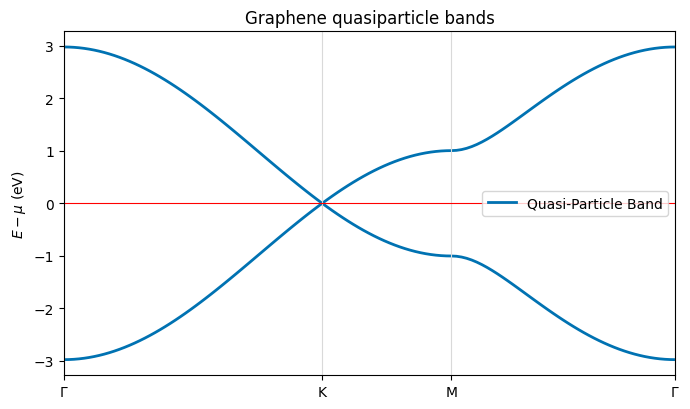

In [8]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
for band in range(tb_bands.shape[0]):
    ax.plot(
        crystal.kdist,
        qp_bands[band],
        color="#0072B2",
        linewidth=2.0,
        label="Quasi-Particle Band" if band == 0 else None,
    )

for node in crystal.knode:
    ax.axvline(node, color="0.85", linewidth=0.8)
ax.axhline(0.0, color="red", linewidth=0.8)
ax.set_xlim(crystal.knode[0], crystal.knode[-1])
ax.set_xticks(crystal.knode)
ax.set_xticklabels(KLable)
ax.set_ylabel(r"$E - \mu$ (eV)")
ax.set_title("Graphene quasiparticle bands")
ax.legend()
fig.tight_layout()
plt.show()

## Exercise

Before running the next cell, guess: does the interaction widen or narrow the bands? Then try changing `KGRID` and rerun from the model cell to see which quantities move.

In [9]:
tb_width = float(tb_bands.max() - tb_bands.min())
qp_width = float(qp_bands.max() - qp_bands.min())

{
    "tight_binding_bandwidth_eV": tb_width,
    "g0w0_bandwidth_eV": qp_width,
    "bandwidth_ratio": qp_width / tb_width,
}

{'tight_binding_bandwidth_eV': 6.0,
 'g0w0_bandwidth_eV': 5.9605879248613585,
 'bandwidth_ratio': 0.9934313208102264}

## Notes and pitfalls

- **Local interaction:** the `V` constructor does not read the local section of `qassemble.in` directly; write the normalized representation by hand as in the model cell.
- **Quasiparticle bands:** QAssemble exposes the arrays and lattice transforms but no ready-made quasiparticle-Hamiltonian helper, so this notebook (like `analyze.py`) builds one.
- **Band values:** `FPathStc.Band` plots or writes `band.dat` rather than returning arrays; to work with the numbers, combine the lattice transforms with `numpy.linalg.eigvalsh` as done above.
- **Real-frequency spectra:** none are computed here. Evaluating noisy Matsubara/DLR coefficients directly is not a controlled analytic continuation, and the existing MQEM path requires an external Julia workflow.
- **Chemical potential:** report `green.mu`; ignore `green.c`.
- **Hidden state:** after changing any model parameter, rerun the notebook from the model cell downward.